# Understanding the Spectral Plot

A **spectral plot** (also called a periodogram or power spectrum) shows how the **variance / energy** of a time series is distributed across different **frequencies**. The x-axis is frequency (cycles per unit time) and the y-axis is the power (squared amplitude) at each frequency. It is the frequency-domain counterpart of the ACF: where ACF shows correlations at different lags in time, the spectral plot shows dominant periodicities in frequency space.

**Key relationships:**
- ACF exponential decay → spectral plot is flat (white noise) or low-frequency dominated
- ACF seasonal spike at lag k → spectral plot has a spike at frequency 1/k
- ACF oscillation → spectral plot has a sharp peak at the oscillation frequency

**How it works (DFT):** The Discrete Fourier Transform decomposes the signal y(t) into a sum of sinusoids. The **power spectral density (PSD)** is the squared modulus |Y(f)|² of the Fourier coefficients, showing how much energy each frequency contributes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

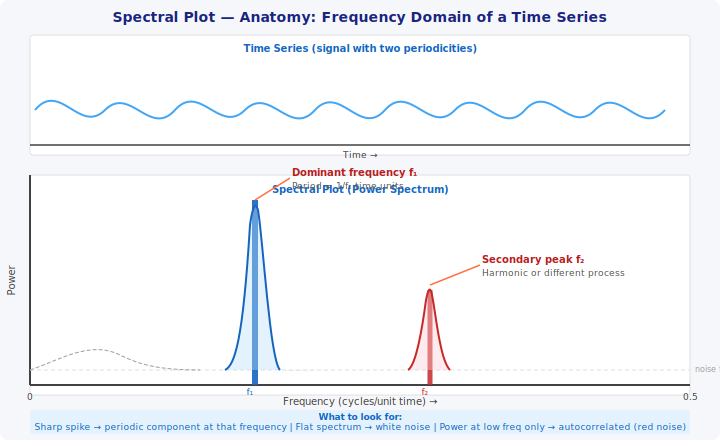

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Spectral Plot — Anatomy: Frequency Domain of a Time Series</text>

  <!-- ── TOP: Time series panel ── -->
  <rect x="30" y="35" width="660" height="120" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="360" y="52" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Time Series (signal with two periodicities)</text>
  <path d="M 35,110 C 60,80 80,135 105,110 C 130,85 150,138 175,110 C 200,82 220,135 245,110
           C 270,85 290,138 315,110 C 340,83 360,138 385,110 C 410,82 430,136 455,110
           C 480,84 500,138 525,110 C 550,82 570,136 595,110 C 620,84 640,138 665,110 680,97"
        fill="none" stroke="#42A5F5" stroke-width="2"/>
  <line x1="30"  y1="145" x2="690" y2="145" stroke="#424242" stroke-width="1.5"/>
  <text x="360" y="158" text-anchor="middle" font-size="9" fill="#424242">Time →</text>

  <!-- ── BOTTOM: Spectral Plot ── -->
  <rect x="30" y="175" width="660" height="220" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="360" y="193" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Spectral Plot (Power Spectrum)</text>

  <!-- Axes -->
  <line x1="30" y1="385" x2="690" y2="385" stroke="#424242" stroke-width="2"/>
  <line x1="30" y1="385" x2="30"  y2="175" stroke="#424242" stroke-width="2"/>
  <text x="360" y="405" text-anchor="middle" font-size="10" fill="#424242">Frequency (cycles/unit time) →</text>
  <text x="15" y="280" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 15 280)">Power</text>

  <!-- Flat baseline (noise floor) -->
  <line x1="30" y1="370" x2="690" y2="370" stroke="#E0E0E0" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="695" y="372" font-size="8" fill="#9E9E9E">noise floor</text>

  <!-- Low frequency noise hump (red noise) -->
  <path d="M 30,370 C 60,360 90,340 120,355 C 140,365 160,370 200,370"
        fill="none" stroke="#9E9E9E" stroke-width="1" stroke-dasharray="4,2"/>

  <!-- Main peak 1: dominant frequency f1 -->
  <line x1="255" y1="385" x2="255" y2="200" stroke="#1565C0" stroke-width="6" opacity="0.9"/>
  <line x1="255" y1="385" x2="255" y2="385" stroke="#1565C0" stroke-width="1"/>
  <!-- Smooth Gaussian shape around peak 1 -->
  <path d="M 225,370 C 235,365 243,340 250,225 C 252,210 255,200 258,210 C 263,240 270,360 280,370 C 290,372 310,370 350,370"
        fill="#BBDEFB" opacity="0.4"/>
  <path d="M 225,370 C 235,365 243,340 250,225 C 252,210 255,200 258,210 C 263,240 270,360 280,370"
        fill="none" stroke="#1565C0" stroke-width="2"/>

  <!-- Peak 1 annotation -->
  <line x1="255" y1="200" x2="290" y2="178" stroke="#FF7043" stroke-width="1.5"/>
  <text x="292" y="176" font-size="10" font-weight="bold" fill="#B71C1C">Dominant frequency f₁</text>
  <text x="292" y="189" font-size="9" fill="#555">Period = 1/f₁ time units</text>
  <text x="250" y="395" text-anchor="middle" font-size="9" fill="#1565C0">f₁</text>

  <!-- Main peak 2: harmonic / secondary frequency f2 -->
  <line x1="430" y1="385" x2="430" y2="290" stroke="#C62828" stroke-width="5" opacity="0.85"/>
  <path d="M 408,370 C 416,365 422,330 426,300 C 428,290 430,285 432,295 C 436,315 440,360 450,370"
        fill="#FFCDD2" opacity="0.4"/>
  <path d="M 408,370 C 416,365 422,330 426,300 C 428,290 430,285 432,295 C 436,315 440,360 450,370"
        fill="none" stroke="#C62828" stroke-width="2"/>

  <!-- Peak 2 annotation -->
  <line x1="430" y1="285" x2="480" y2="265" stroke="#FF7043" stroke-width="1.5"/>
  <text x="482" y="263" font-size="10" font-weight="bold" fill="#B71C1C">Secondary peak f₂</text>
  <text x="482" y="276" font-size="9" fill="#555">Harmonic or different process</text>
  <text x="425" y="395" text-anchor="middle" font-size="9" fill="#C62828">f₂</text>

  <!-- Frequency axis ticks -->
  <text x="30"  y="400" text-anchor="middle" font-size="9" fill="#424242">0</text>
  <text x="690" y="400" text-anchor="middle" font-size="9" fill="#424242">0.5</text>

  <!-- Takeaway -->
  <rect x="30" y="410" width="660" height="24" fill="#E3F2FD" rx="3"/>
  <text x="360" y="420" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="430" text-anchor="middle" font-size="9" fill="#1565C0">Sharp spike → periodic component at that frequency   |   Flat spectrum → white noise   |   Power at low freq only → autocorrelated (red noise)</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Spectral Plot

| Pattern | What it means |
|---|---|
| **Flat spectrum** | White noise — no periodic structure, all frequencies equal power |
| **Single sharp spike at f** | One dominant periodic component with period T=1/f |
| **Multiple spikes** | Multiple overlapping periodicities in the data |
| **Spikes at f, 2f, 3f** | Fundamental + harmonics — non-sinusoidal periodic signal |
| **Power concentrated at low freq** | Red noise / autocorrelated process — long-range dependence |
| **Broad hump** | Quasi-periodic or weakly seasonal component |
| **1/f power law slope** | Fractal / long-memory process (pink noise) |

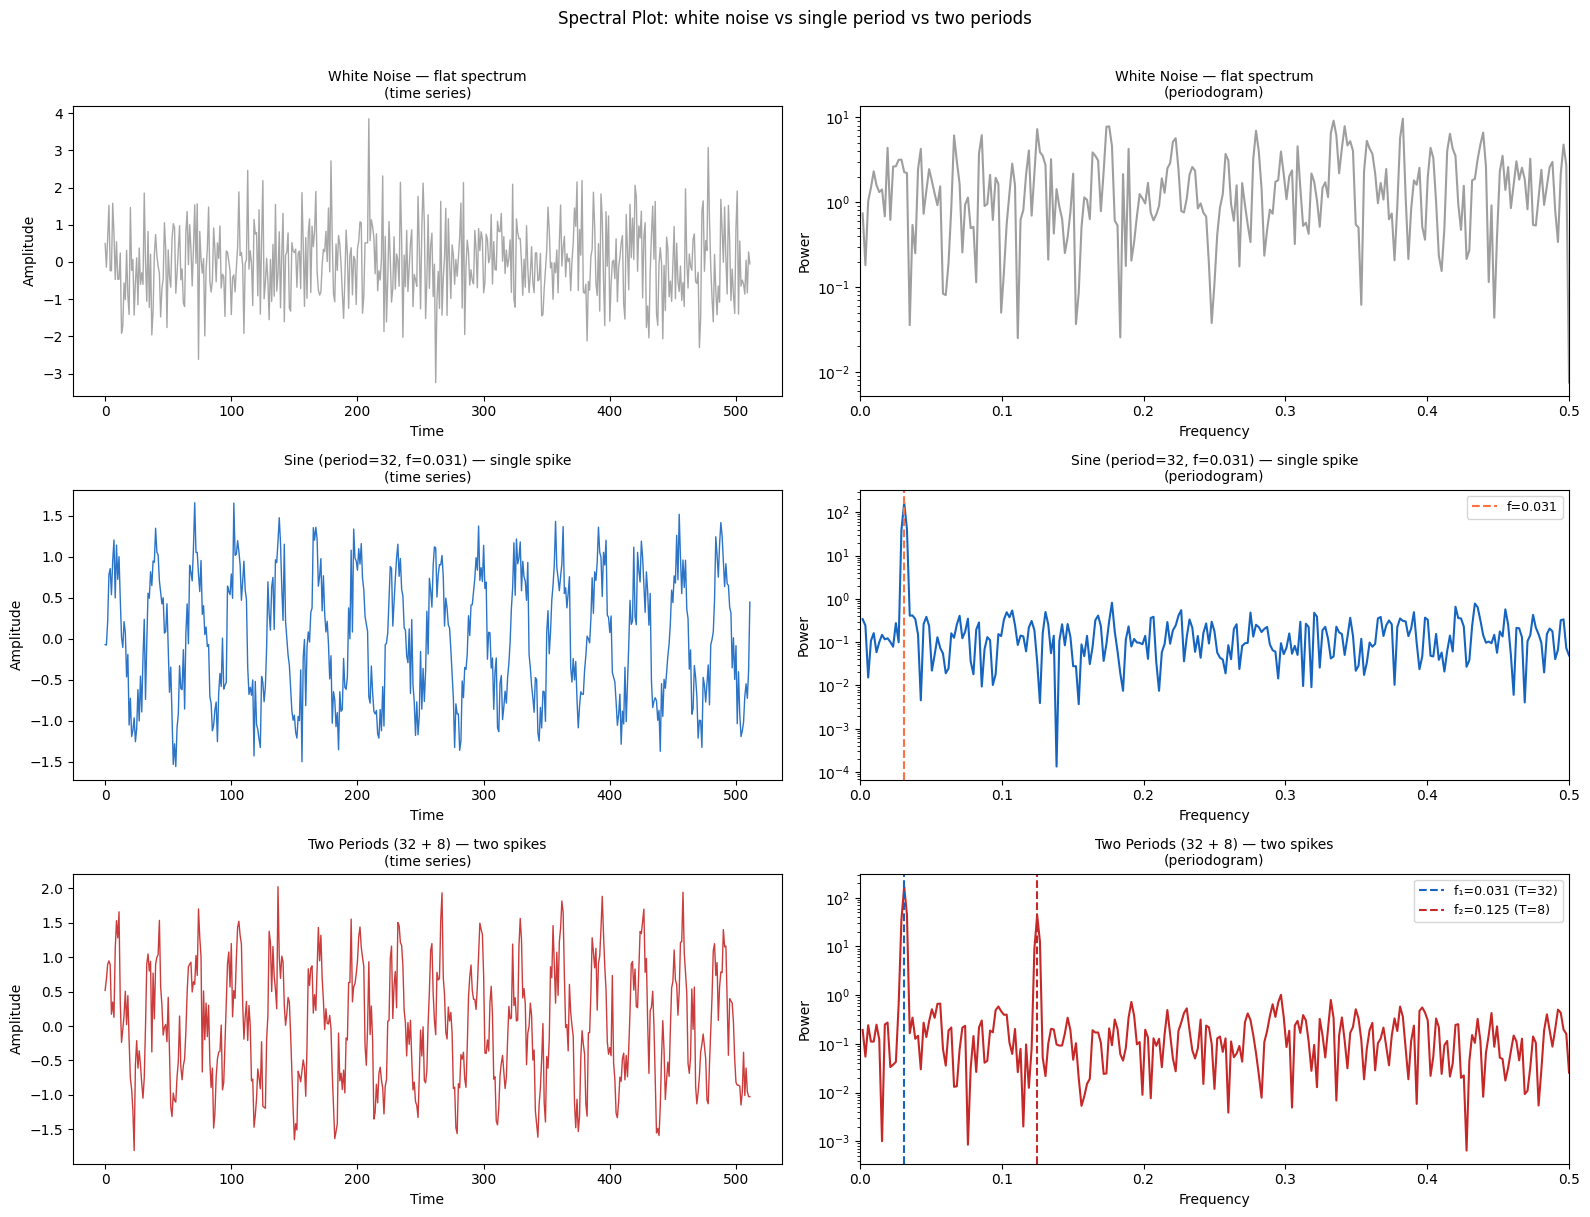

In [3]:
np.random.seed(42)
n = 512
t = np.arange(n)
fs = 1.0  # sampling frequency

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

def plot_spectral_pair(ax_ts, ax_spec, signal_data, title, color='#1565C0'):
    ax_ts.plot(t, signal_data, color=color, linewidth=1, alpha=0.9)
    ax_ts.set_title(f'{title}\n(time series)', fontsize=10)
    ax_ts.set_xlabel('Time')
    ax_ts.set_ylabel('Amplitude')

    freqs, psd = signal.periodogram(signal_data, fs=fs, window='hann')
    ax_spec.semilogy(freqs[1:], psd[1:], color=color, linewidth=1.5)
    ax_spec.set_title(f'{title}\n(periodogram)', fontsize=10)
    ax_spec.set_xlabel('Frequency')
    ax_spec.set_ylabel('Power')
    ax_spec.set_xlim(0, 0.5)

# Case 1: White noise
white = np.random.normal(0, 1, n)
plot_spectral_pair(axes[0,0], axes[0,1], white, 'White Noise — flat spectrum', '#9E9E9E')

# Case 2: Single sine (one dominant period)
f1 = 1/32  # period=32
sine = np.sin(2*np.pi*f1*t) + 0.3*np.random.normal(0, 1, n)
plot_spectral_pair(axes[1,0], axes[1,1], sine, f'Sine (period=32, f={f1:.3f}) — single spike', '#1565C0')
axes[1,1].axvline(f1, color='#FF7043', linewidth=1.5, linestyle='--', label=f'f={f1:.3f}')
axes[1,1].legend(fontsize=9)

# Case 3: Two periodicities (period 32 and period 8)
f2 = 1/8
two_sine = (np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)
            + 0.3*np.random.normal(0, 1, n))
plot_spectral_pair(axes[2,0], axes[2,1], two_sine, 'Two Periods (32 + 8) — two spikes', '#C62828')
axes[2,1].axvline(f1, color='#1565C0', linewidth=1.5, linestyle='--', label=f'f₁={f1:.3f} (T=32)')
axes[2,1].axvline(f2, color='#C62828', linewidth=1.5, linestyle='--', label=f'f₂={f2:.3f} (T=8)')
axes[2,1].legend(fontsize=9)

plt.suptitle('Spectral Plot: white noise vs single period vs two periods', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Detecting periodic structure in time series |
| **x-axis** | Frequency (0 to Nyquist = fs/2) |
| **y-axis** | Power (energy at that frequency) |
| **Sharp spike** | Deterministic periodic component at that frequency |
| **Period** | T = 1/f (inverse of the spike's frequency) |
| **Flat spectrum** | White noise — no periodicity |
| **Low-frequency hump** | Autocorrelated process (red noise) |
| **vs ACF** | ACF: lags in time-domain; Spectrum: frequencies in freq-domain — equivalent information, different view |
| **Windowing** | Use Hann or Hamming window to reduce spectral leakage from finite-length signals |
| **Log scale for y** | Use `semilogy` to see both large peaks and the noise floor |